# 02 - Treino DNN (NumPy)

Random search focado na vizinhança da configuração final, usando a lógica do `scripts/ensemble_3_models.py`.
Cada trial treina em `dataset_combined + dataset-exemplos`, faz early stopping em `subm1` e avalia em `subm2`.


In [7]:
import sys
import os
import pickle
import random
import time

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, f1_score, roc_curve
from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.hyperopt import build_random_search
from src.models_numpy.dnn import (
    AdamOptimizer,
    BatchNormalizationLayer,
    CategoricalCrossEntropy,
    Dataset,
    DenseLayer,
    DropoutLayer,
    NeuralNetwork,
    ReLUActivation,
    SoftmaxActivation,
    accuracy,
)
from src.vectorizer import create_vectorizer


In [8]:
SEED = 42
N_ITERATIONS = 12

random.seed(SEED)
np.random.seed(SEED)


## 1. Dados


In [9]:
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
EXEMPLOS_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
EARLY_STOP_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')
EVAL_PATH = os.path.join(ROOT, 'data', 'validation', 'subm2_labels_revealed.csv')
SAVED_MODELS_DIR = os.path.join(ROOT, 'saved_models')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


def one_hot(labels):
    oh = np.zeros((len(labels), NUM_CLASSES))
    for i, label in enumerate(labels):
        oh[i, label] = 1
    return oh


df_train = load_data(TRAIN_PATH)
df_exemplos = load_data(EXEMPLOS_PATH)
df_full = pd.concat([df_train, df_exemplos], ignore_index=True)
df_es = load_data(EARLY_STOP_PATH)
df_eval = load_data(EVAL_PATH)

print(f'Train final: {len(df_full)} (combined={len(df_train)} + exemplos={len(df_exemplos)})')
print(f'Early stop (subm1): {len(df_es)}')
print(f'Eval (subm2): {len(df_eval)}')


Train final: 4740 (combined=4615 + exemplos=125)
Early stop (subm1): 100
Eval (subm2): 100


## 2. Espaço de Busca


In [10]:
param_grid = {
    'vectorizer_type': ['forensic'],
    'max_words': [1500, 2000, 2500],
    'hidden_layers': [[128, 64], [256, 128], [256, 128, 64]],
    'dropout': [0.3, 0.4, 0.5],
    'lr': [0.0005, 0.001, 0.002],
    'batch_size': [64],
    'use_batchnorm': [True, False],
    'epochs': [100],
    'patience': [15],
}

for k, v in param_grid.items():
    print(f'{k}: {v}')


vectorizer_type: ['forensic']
max_words: [1500, 2000, 2500]
hidden_layers: [[128, 64], [256, 128], [256, 128, 64]]
dropout: [0.3, 0.4, 0.5]
lr: [0.0005, 0.001, 0.002]
batch_size: [64]
use_batchnorm: [True, False]
epochs: [100]
patience: [15]


## 3. Funções


In [11]:
def build_dnn(params, input_dim):
    model = NeuralNetwork(
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        optimizer=AdamOptimizer(learning_rate=params['lr']),
        verbose=False,
        loss=CategoricalCrossEntropy,
        metric=accuracy,
        early_stopping=True,
        patience=params['patience'],
    )

    prev_dim = input_dim
    for hidden_dim in params['hidden_layers']:
        model.add(DenseLayer(hidden_dim, prev_dim))
        if params['use_batchnorm']:
            model.add(BatchNormalizationLayer())
        model.add(ReLUActivation())
        model.add(DropoutLayer(params['dropout']))
        prev_dim = hidden_dim

    model.add(DenseLayer(NUM_CLASSES, prev_dim))
    model.add(SoftmaxActivation())
    return model


def train_dnn_trial(params, texts_tr, y_tr, texts_es, y_es):
    texts_tr_clean = [clean_text(text) for text in texts_tr]
    texts_es_clean = [clean_text(text) for text in texts_es]

    vectorizer = create_vectorizer(params['vectorizer_type'], max_words=params['max_words'])
    X_tr = vectorizer.fit_transform(texts_tr_clean, texts_tr)
    X_es = vectorizer.transform(texts_es_clean, texts_es)

    model = build_dnn(params, X_tr.shape[1])
    start = time.time()
    history = model.fit(
        Dataset(X_tr, one_hot(y_tr)),
        Dataset(X_es, one_hot(y_es)),
    )
    train_time = time.time() - start
    return model, vectorizer, history, train_time


def predict_dnn(model, vectorizer, texts_raw):
    texts_clean = [clean_text(text) for text in texts_raw]
    X = vectorizer.transform(texts_clean, texts_raw)
    return model.predict(Dataset(X, np.zeros((len(texts_raw), NUM_CLASSES))))


def evaluate_probs(probs, labels, name):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.tight_layout()
    plt.show()
    return acc, macro_f1, preds


## 4. Random Search com Protocolo Final


In [12]:
results = []
best_selection_score = -1.0
best_payload = None

texts_tr = df_full['Text'].tolist()
y_tr = df_full['label_id'].values
texts_es = df_es['Text'].tolist()
y_es = df_es['label_id'].values
texts_eval = df_eval['Text'].tolist()
y_eval = df_eval['label_id'].values

for i, params in enumerate(build_random_search(param_grid, n_iter=N_ITERATIONS, random_state=SEED), start=1):
    print(f"[{i}/{N_ITERATIONS}] hidden={params['hidden_layers']} drop={params['dropout']} lr={params['lr']} mw={params['max_words']}")

    model, vectorizer, history, train_time = train_dnn_trial(params, texts_tr, y_tr, texts_es, y_es)
    probs_es = predict_dnn(model, vectorizer, texts_es)
    probs_eval = predict_dnn(model, vectorizer, texts_eval)

    es_acc = accuracy_score(y_es, np.argmax(probs_es, axis=1))
    eval_acc = accuracy_score(y_eval, np.argmax(probs_eval, axis=1))
    es_f1 = f1_score(y_es, np.argmax(probs_es, axis=1), average='macro', zero_division=0)
    eval_f1 = f1_score(y_eval, np.argmax(probs_eval, axis=1), average='macro', zero_division=0)
    selection_score = (es_acc + eval_acc) / 2

    print(f'  -> ES acc={es_acc:.4f} f1={es_f1:.4f} | Eval acc={eval_acc:.4f} f1={eval_f1:.4f} | score={selection_score:.4f}')

    results.append({
        'iteration': i,
        'vectorizer_type': params['vectorizer_type'],
        'max_words': params['max_words'],
        'hidden_layers': str(params['hidden_layers']),
        'dropout': params['dropout'],
        'lr': params['lr'],
        'batch_size': params['batch_size'],
        'use_batchnorm': params['use_batchnorm'],
        'es_acc': es_acc,
        'es_f1': es_f1,
        'eval_acc': eval_acc,
        'eval_f1': eval_f1,
        'selection_score': selection_score,
        'train_time': train_time,
    })

    if selection_score > best_selection_score:
        best_selection_score = selection_score
        best_payload = {
            'params': params.copy(),
            'model': model,
            'vectorizer': vectorizer,
            'probs_es': probs_es,
            'probs_eval': probs_eval,
        }
        print('  *** NOVO MELHOR MODELO ***')

results_df = pd.DataFrame(results).sort_values(['selection_score', 'eval_acc', 'es_acc'], ascending=False).reset_index(drop=True)
results_df.head()


[1/12] hidden=[256, 128, 64] drop=0.4 lr=0.0005 mw=1500
  -> ES acc=0.5900 f1=0.5425 | Eval acc=0.6800 f1=0.6609 | score=0.6350
  *** NOVO MELHOR MODELO ***
[2/12] hidden=[128, 64] drop=0.3 lr=0.0005 mw=1500
  -> ES acc=0.6100 f1=0.5724 | Eval acc=0.7400 f1=0.7179 | score=0.6750
  *** NOVO MELHOR MODELO ***
[3/12] hidden=[256, 128, 64] drop=0.4 lr=0.0005 mw=2000
  -> ES acc=0.5600 f1=0.5051 | Eval acc=0.6200 f1=0.5723 | score=0.5900
[4/12] hidden=[256, 128] drop=0.3 lr=0.0005 mw=1500
  -> ES acc=0.6500 f1=0.6262 | Eval acc=0.6600 f1=0.6402 | score=0.6550
[5/12] hidden=[256, 128, 64] drop=0.4 lr=0.002 mw=1500
  -> ES acc=0.5700 f1=0.5201 | Eval acc=0.7300 f1=0.7054 | score=0.6500
[6/12] hidden=[128, 64] drop=0.5 lr=0.0005 mw=2500
  -> ES acc=0.6600 f1=0.6302 | Eval acc=0.7100 f1=0.6858 | score=0.6850
  *** NOVO MELHOR MODELO ***
[7/12] hidden=[256, 128] drop=0.4 lr=0.001 mw=1500
  -> ES acc=0.6600 f1=0.6227 | Eval acc=0.7000 f1=0.6748 | score=0.6800
[8/12] hidden=[256, 128] drop=0.5 lr=

,iteration,vectorizer_type,max_words,hidden_layers,dropout,lr,batch_size,use_batchnorm,es_acc,es_f1,eval_acc,eval_f1,selection_score,train_time
0,6,forensic,2500,"[128, 64]",0.5,0.0005,64,True,0.66,0.630242,0.71,0.685839,0.685,46.679528
1,7,forensic,1500,"[256, 128]",0.4,0.0010,64,True,0.66,0.622664,0.70,0.674753,0.680,53.846201
2,2,forensic,1500,"[128, 64]",0.3,0.0005,64,True,0.61,0.572368,0.74,0.717856,0.675,8.165786
3,8,forensic,2500,"[256, 128]",0.5,0.0020,64,True,0.62,0.575391,0.72,0.706561,0.670,75.753367
4,11,forensic,2500,"[256, 128]",0.3,0.0010,64,True,0.63,0.601069,0.69,0.664205,0.660,65.316634


## 5. Resultados


 iteration vectorizer_type  max_words  hidden_layers  dropout     lr  batch_size  use_batchnorm  es_acc    es_f1  eval_acc  eval_f1  selection_score  train_time
         6        forensic       2500      [128, 64]      0.5 0.0005          64           True    0.66 0.630242      0.71 0.685839            0.685   46.679528
         7        forensic       1500     [256, 128]      0.4 0.0010          64           True    0.66 0.622664      0.70 0.674753            0.680   53.846201
         2        forensic       1500      [128, 64]      0.3 0.0005          64           True    0.61 0.572368      0.74 0.717856            0.675    8.165786
         8        forensic       2500     [256, 128]      0.5 0.0020          64           True    0.62 0.575391      0.72 0.706561            0.670   75.753367
        11        forensic       2500     [256, 128]      0.3 0.0010          64           True    0.63 0.601069      0.69 0.664205            0.660   65.316634
         4        forensic       1

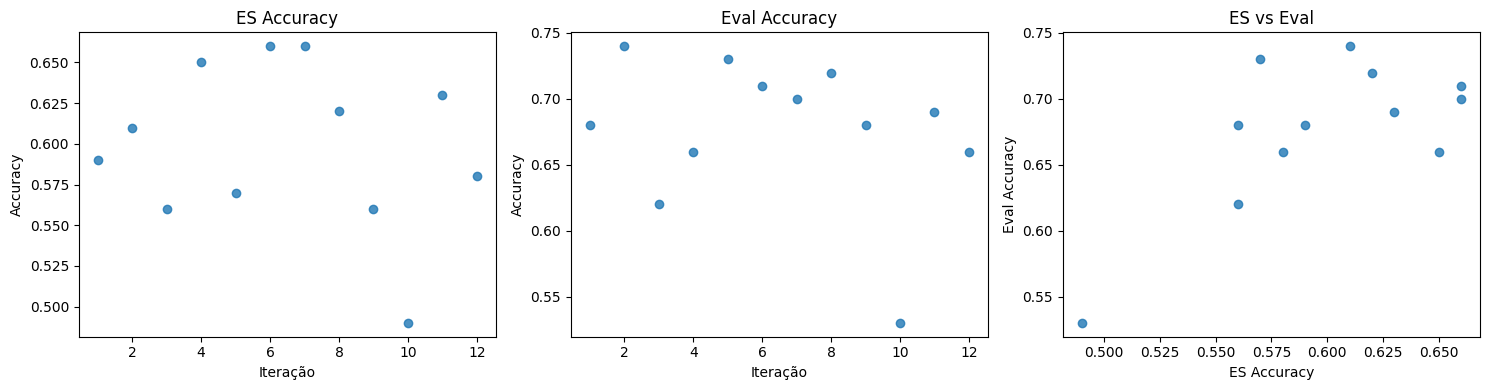

In [13]:
print(results_df.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(results_df['iteration'], results_df['es_acc'], alpha=0.8)
axes[0].set_title('ES Accuracy')
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Accuracy')

axes[1].scatter(results_df['iteration'], results_df['eval_acc'], alpha=0.8)
axes[1].set_title('Eval Accuracy')
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Accuracy')

axes[2].scatter(results_df['es_acc'], results_df['eval_acc'], alpha=0.8)
axes[2].set_title('ES vs Eval')
axes[2].set_xlabel('ES Accuracy')
axes[2].set_ylabel('Eval Accuracy')

plt.tight_layout()
plt.show()


## 6. Avaliação do Melhor Modelo


{'vectorizer_type': 'forensic', 'max_words': 2500, 'hidden_layers': [128, 64], 'dropout': 0.5, 'lr': 0.0005, 'batch_size': 64, 'use_batchnorm': True, 'epochs': 100, 'patience': 15}
Selection score: 0.6850

=== Melhor DNN - ES (subm1) ===
Accuracy: 0.6600 | Macro F1: 0.6302
              precision    recall  f1-score   support

   Anthropic       0.82      0.53      0.64        17
      Google       0.56      0.59      0.57        17
       Human       0.77      0.79      0.78        34
        Meta       0.68      0.72      0.70        18
      OpenAI       0.41      0.50      0.45        14

    accuracy                           0.66       100
   macro avg       0.65      0.63      0.63       100
weighted avg       0.68      0.66      0.66       100



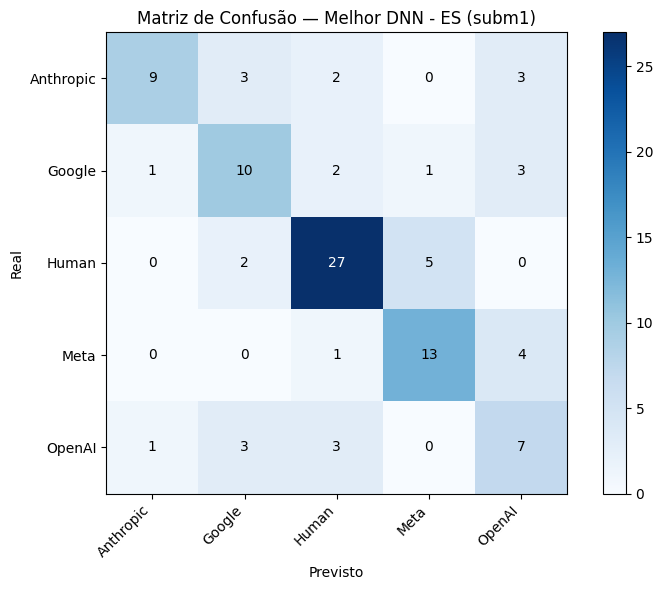


=== Melhor DNN - Eval (subm2) ===
Accuracy: 0.7100 | Macro F1: 0.6858
              precision    recall  f1-score   support

   Anthropic       0.58      0.44      0.50        16
      Google       0.67      0.67      0.67        18
       Human       0.93      0.74      0.82        34
        Meta       0.68      0.81      0.74        16
      OpenAI       0.58      0.88      0.70        16

    accuracy                           0.71       100
   macro avg       0.69      0.71      0.69       100
weighted avg       0.73      0.71      0.71       100



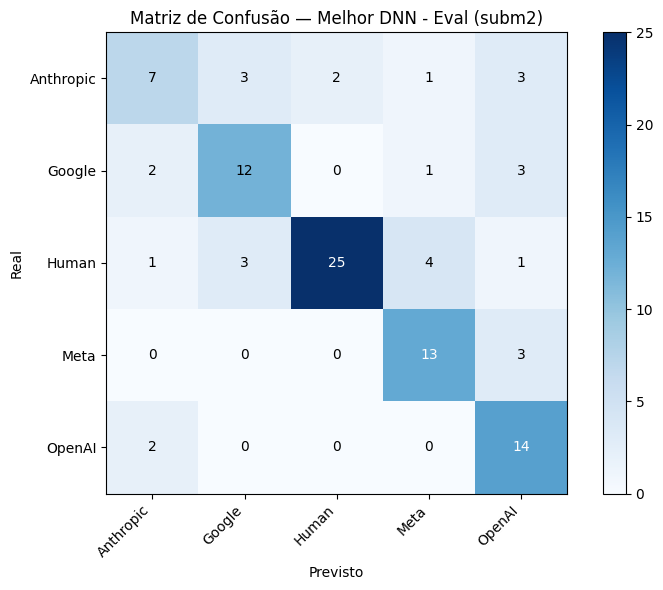

In [14]:
best_model = best_payload['model']
best_vectorizer = best_payload['vectorizer']
best_params = best_payload['params']

print(best_params)
print(f'Selection score: {best_selection_score:.4f}')

es_acc, es_f1, _ = evaluate_probs(best_payload['probs_es'], y_es, 'Melhor DNN - ES (subm1)')
eval_acc, eval_f1, _ = evaluate_probs(best_payload['probs_eval'], y_eval, 'Melhor DNN - Eval (subm2)')


## 7. Guardar Pesos


In [15]:
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
results_path = os.path.join(ROOT, 'data', 'processed', 'dnn_search_results.csv')
model_path = os.path.join(SAVED_MODELS_DIR, 'dnn_final_model.npz')
vectorizer_path = os.path.join(SAVED_MODELS_DIR, 'dnn_final_vectorizer.pkl')

results_df.to_csv(results_path, index=False)
best_model.save(model_path)
with open(vectorizer_path, 'wb') as f:
    pickle.dump(best_vectorizer, f)

print(f'Resultados guardados em {results_path}')
print(f'Modelo guardado em {model_path}')
print(f'Vectorizer guardado em {vectorizer_path}')


Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/data/processed/dnn_search_results.csv
Modelo guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/dnn_final_model.npz
Vectorizer guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/dnn_final_vectorizer.pkl
